In [1]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)

path = "/home/students/studweilc1/MU-Diff/"
# add this to path for imports
if path not in sys.path:
    sys.path.append(path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from dataset.dataset_dixon import CreateDatasetSynthesis, CreateDatasetSynthesis_single_with_masks


In [3]:
data_dixon = np.load("../data/my_data3/test/DIXON.npy")
data_t1 = np.load("../data/my_data3/test/T1_mapping_fl2d.npy")
data_dixon_masks = np.load("../data/my_data3/test/DIXON_masks.npy")
data_t1_masks = np.load("../data/my_data3/test/T1_mapping_fl2d_masks.npy")

sample_dixon = data_dixon[0]
sample_t1 = data_t1[0]

In [4]:
input_path = "../data/my_data3"
batch_size = 1
dataset_val= CreateDatasetSynthesis_single_with_masks(phase="val", input_path=input_path, contrast="T1_mapping_fl2d", target_contrast="DIXON")

data_loader = torch.utils.data.DataLoader(dataset_val,
                                                batch_size=1,
                                                shuffle=False,
                                                num_workers=1,
                                                pin_memory=False,
                                                drop_last=True)

# set requires grad to false
data_loader.require_grad = False

padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0


In [5]:

input_path = "../data/transformed_data"
batch_size = 1
dataset_val_affine = CreateDatasetSynthesis_single_with_masks(phase="val", input_path=input_path, contrast="T1_mapping_fl2d", target_contrast="DIXON")

data_loader_val_affine = torch.utils.data.DataLoader(dataset_val_affine,
                                                batch_size=1,
                                                shuffle=False,
                                                num_workers=1,
                                                pin_memory=False,
                                                drop_last=True)

# set requires grad to false
data_loader_val_affine.require_grad = False

padding in x-y with:0-0
padding in x-y with:0-0


padding in x-y with:0-0
padding in x-y with:0-0


In [6]:
for i , data in enumerate(data_loader):
    x_data, x_target, mask_data, mask_target = data
    break

In [7]:
for i , data in enumerate(data_loader_val_affine):
    x_data_affine, x_target_affine, mask_data_affine, mask_target_affine = data
    break

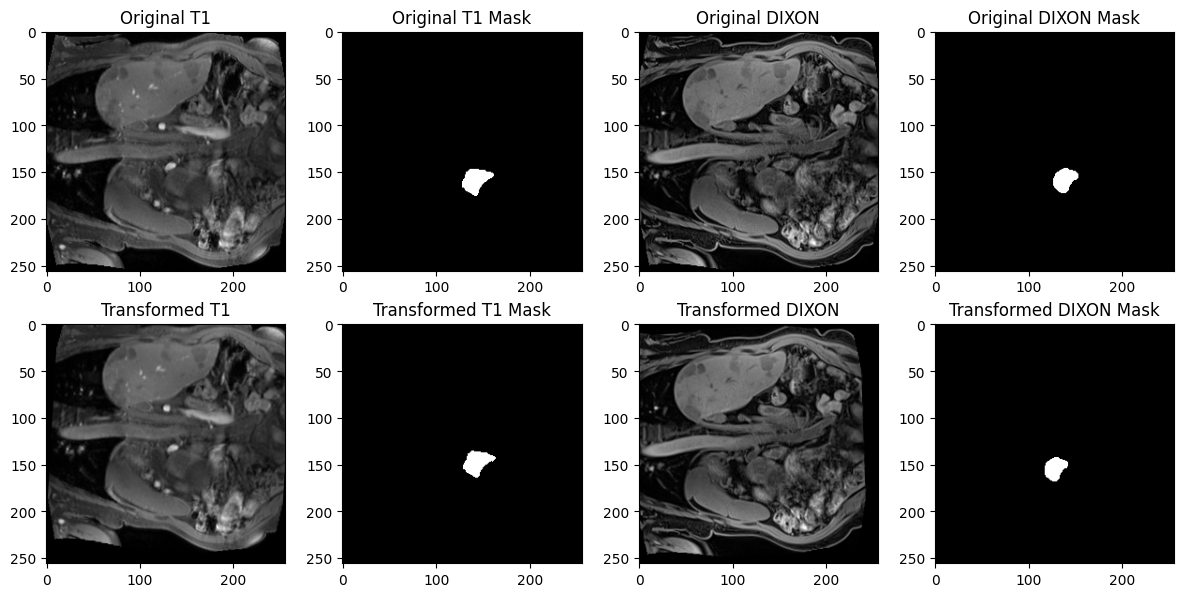

In [8]:
fig, ax = plt.subplots(2,4, figsize=(12,6))
ax[0,0].imshow(x_data[0,0].cpu().numpy(), cmap='gray')
ax[0,0].set_title("Original T1")
ax[0,1].imshow(mask_data[0,0].cpu().numpy(), cmap='gray')
ax[0,1].set_title("Original T1 Mask")
ax[0,2].imshow(x_target[0,0].cpu().numpy(), cmap='gray')
ax[0,2].set_title("Original DIXON")
ax[0,3].imshow(mask_target[0,0].cpu().numpy(), cmap='gray')
ax[0,3].set_title("Original DIXON Mask")
ax[1,0].imshow(x_data_affine[0,0].cpu().numpy(), cmap='gray')
ax[1,0].set_title("Transformed T1")
ax[1,1].imshow(mask_data_affine[0,0].cpu().numpy(), cmap='gray')
ax[1,1].set_title("Transformed T1 Mask")
ax[1,2].imshow(x_target_affine[0,0].cpu().numpy(), cmap='gray')
ax[1,2].set_title("Transformed DIXON")
ax[1,3].imshow(mask_target_affine[0,0].cpu().numpy(), cmap='gray')
ax[1,3].set_title("Transformed DIXON Mask")
plt.tight_layout()

Text(0.5, 1.0, 'Difference DIXON')

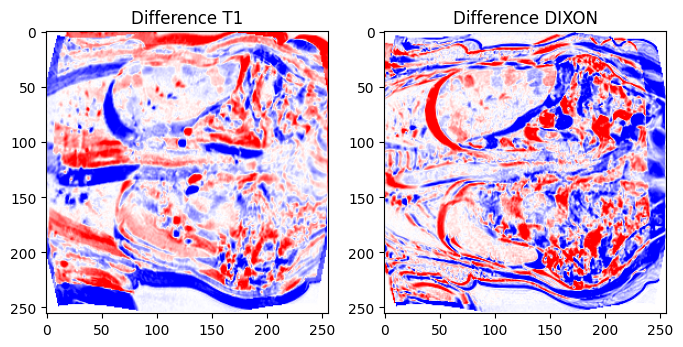

In [9]:
diff_data = x_data_affine - x_data
diff_target = x_target_affine - x_target

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(diff_data[0,0].cpu().numpy(), cmap='bwr', vmin=-0.5, vmax=0.5)
ax[0].set_title("Difference T1")
ax[1].imshow(diff_target[0,0].cpu().numpy(), cmap='bwr', vmin=-0.5, vmax=0.5)
ax[1].set_title("Difference DIXON")

## Test

In [10]:
from losses import loss_dict

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [43]:
for name, loss_fct in loss_dict.items():
    print(loss_fct(x_data, x_target))

-0.3355
-0.0006
0.6888
-1.4258
0.1462
0.0509
0.0167
0.6373
0.4608


In [ ]:
import pandas as pd
class Results:
    def __init__(self, loss_dict):
        self.loss_dict = loss_dict
        for loss_name in loss_dict.keys():
            setattr(self, loss_name, [])
        self.case = []
        self.data_contrast = []
        self.target_contrast = []


    def compute_losses(self, x_data, x_target, x_mask, target_mask, case, data_contrast, target_contrast):
        for loss_name, loss_fn in self.loss_dict.items():
            loss = loss_fn(x_data, x_target)
            getattr(self, loss_name).append(loss)

        dice_loss = 
        self.case.append(case)
        self.data_contrast.append(data_contrast)
        self.target_contrast.append(target_contrast)

    def build_dataframe(self):
        data = {
            "Case": self.case,
            "Data_Contrast": self.data_contrast,
            "Target_Contrast": self.target_contrast
        }
        for loss_name in self.loss_dict.keys():
            data[loss_name] = self.__dict__[loss_name]
        df = pd.DataFrame(data)
        return df




In [24]:
res = Results(loss_dict)
res.compute_losses(x_data, x_target, "Test", "T1", "DIXON")

In [25]:
res.compute_losses(x_data_affine, x_target_affine,  "Affine", "T1", "DIXON")

In [26]:
res.LNCC_Monai

[np.float64(-0.3205), np.float64(-0.2477)]

In [27]:
df = res.build_dataframe()

In [28]:
df

,Case,Data_Contrast,Target_Contrast,LNCC_Monai,MI_Monai,SSIM_Monai,NMI_Loss,MIND_SSC_Loss,SSD_Loss,Blurred_SSD_Loss,Squared_LNCC_Loss,New_LNCC_Loss,PSNR_Loss
0,Test,T1,DIXON,-0.3205,-0.0017,0.7301,-1.4921,0.1612,0.0566,0.0179,0.6782,0.4975,17.8104
1,Affine,T1,DIXON,-0.2477,-0.0006,0.8730,-1.3886,0.2428,0.1174,0.0608,0.8252,0.8115,14.5045
